In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/taxi_trip_pricing.csv")

In [4]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [5]:
df.tail()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090
999,22.85,Morning,Weekend,3.0,Medium,Clear,4.34,NaN,0.23,29.69,45.4437


In [6]:
df.shape

(1000, 11)

In [7]:
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 86.1 KB


In [9]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [11]:
df.describe(include="str")

,Time_of_Day,Day_of_Week,Traffic_Conditions,Weather
count,950,950,950,950
unique,4,2,3,3
top,Afternoon,Weekday,Low,Clear
freq,371,655,397,667


In [12]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [14]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_percentage

Trip_Distance_km         5.0
Time_of_Day              5.0
Day_of_Week              5.0
Passenger_Count          5.0
Traffic_Conditions       5.0
Weather                  5.0
Base_Fare                5.0
Per_Km_Rate              5.0
Per_Minute_Rate          5.0
Trip_Duration_Minutes    5.0
Trip_Price               4.9
dtype: float64

In [15]:
missing_table = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing_table = missing_table.sort_values(
    by="Missing_Percentage",
    ascending=False
)

missing_table

,Missing_Count,Missing_Percentage
Trip_Distance_km,50,5.0
Time_of_Day,50,5.0
Day_of_Week,50,5.0
Passenger_Count,50,5.0
Traffic_Conditions,50,5.0
Weather,50,5.0
Base_Fare,50,5.0
Per_Km_Rate,50,5.0
Per_Minute_Rate,50,5.0
Trip_Duration_Minutes,50,5.0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df.duplicated()]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price


In [18]:
categorical_columns = df.select_dtypes(include="str").columns

categorical_columns

Index(['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], dtype='str')

In [21]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Time_of_Day
<StringArray>
['Morning', 'Afternoon', 'Evening', 'Night', nan]
Length: 5, dtype: str

Day_of_Week
<StringArray>
['Weekday', 'Weekend', nan]
Length: 3, dtype: str

Traffic_Conditions
<StringArray>
['Low', 'High', 'Medium', nan]
Length: 4, dtype: str

Weather
<StringArray>
['Clear', nan, 'Rain', 'Snow']
Length: 4, dtype: str


In [22]:
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Time_of_Day: 4 unique values
Day_of_Week: 2 unique values
Traffic_Conditions: 3 unique values
Weather: 3 unique values


In [23]:
target = "Trip_Price"

In [25]:
df[target].describe()

count    951.000000
mean      56.874773
std       40.469791
min        6.126900
25%       33.742650
50%       50.074500
75%       69.099350
max      332.043689
Name: Trip_Price, dtype: float64

In [26]:
df[target].isnull().sum()

np.int64(49)

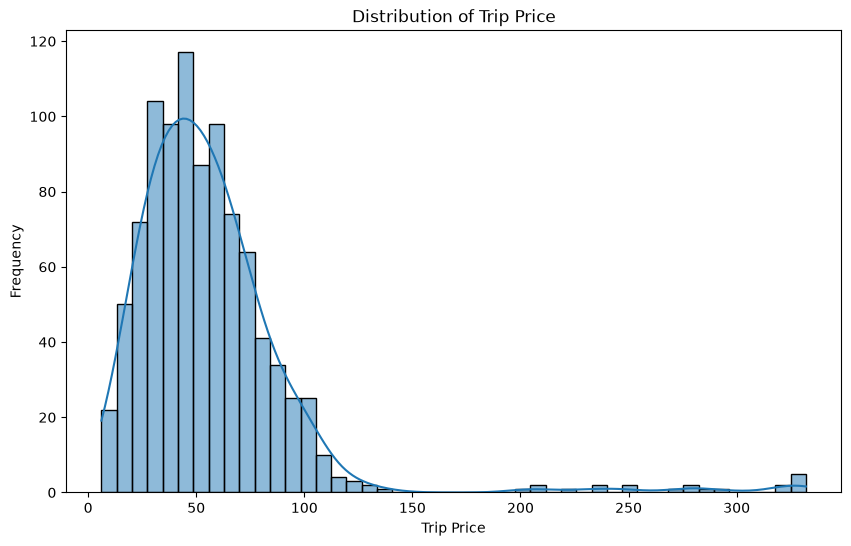

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Trip_Price",
    kde=True
)

plt.title("Distribution of Trip Price")
plt.xlabel("Trip Price")
plt.ylabel("Frequency")

plt.show()

In [30]:
numerical_columns = df.select_dtypes(include="number").columns

numerical_columns

Index(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='str')

In [29]:
numerical_features = [col for col in numerical_columns if col not in ["id", "Trip_Price"]]

numerical_features

['Trip_Distance_km',
 'Passenger_Count',
 'Base_Fare',
 'Per_Km_Rate',
 'Per_Minute_Rate',
 'Trip_Duration_Minutes']

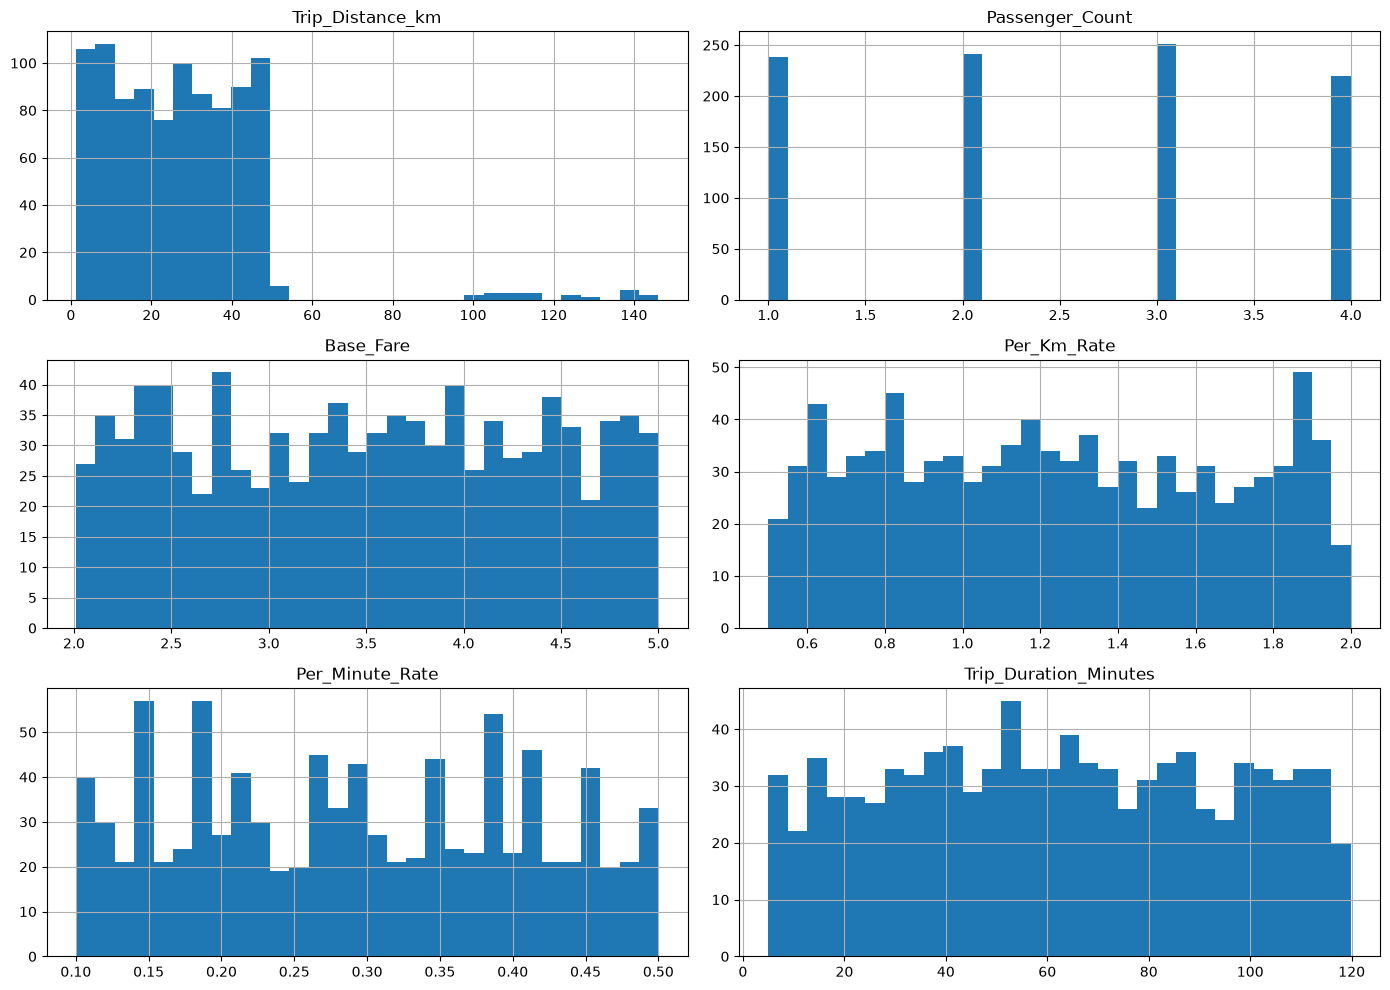

In [31]:
df[numerical_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

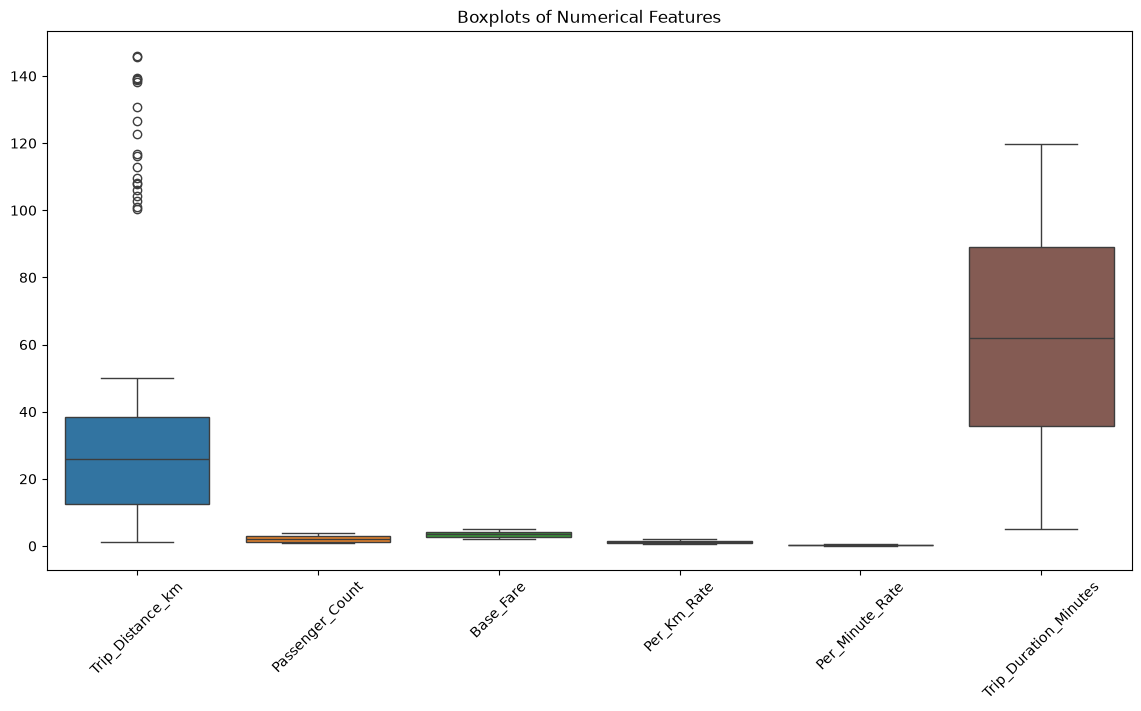

In [32]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[numerical_features]
)

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")

plt.show()

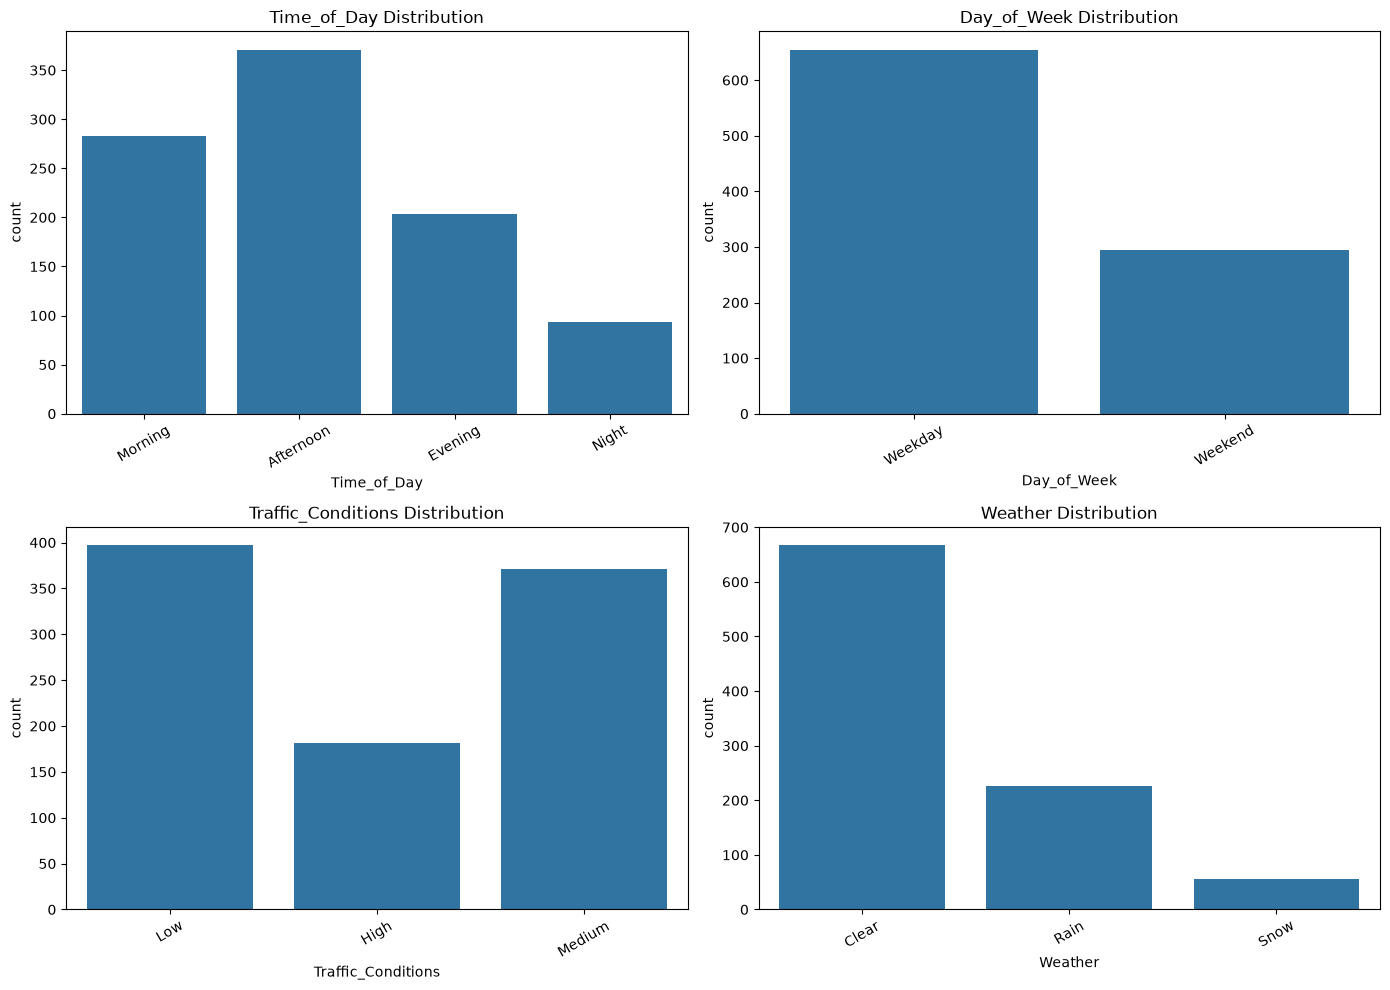

In [33]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

for ax, col in zip(
    axes.flatten(),
    categorical_columns
):
    sns.countplot(
        data=df,
        x=col,
        ax=ax
    )

    ax.set_title(f"{col} Distribution")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

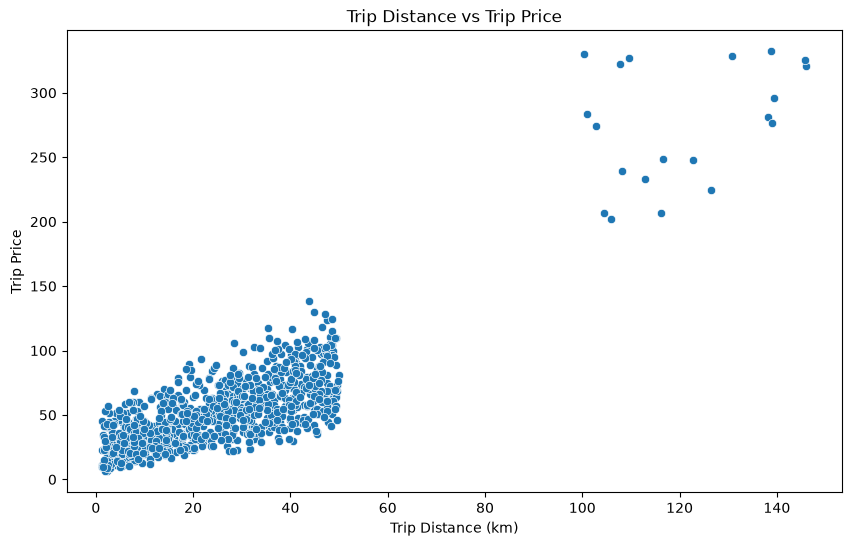

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Trip_Distance_km",
    y="Trip_Price"
)

plt.title("Trip Distance vs Trip Price")
plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Price")

plt.show()

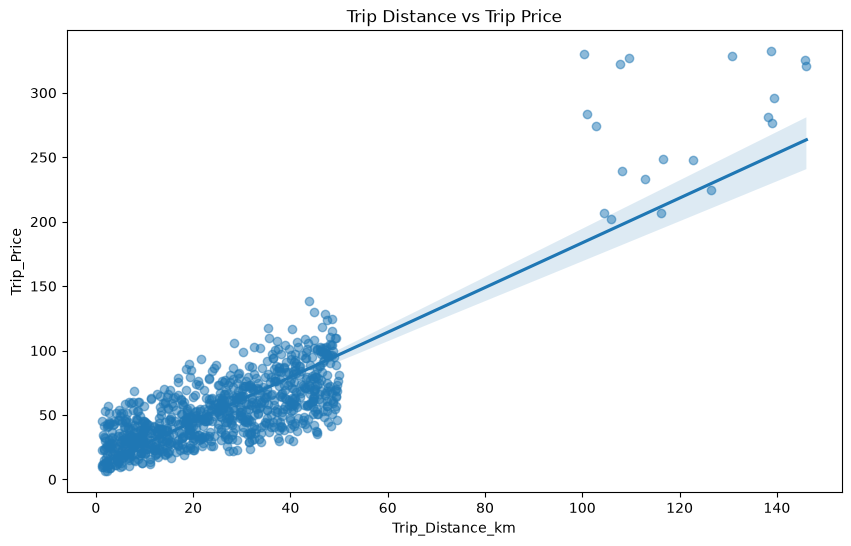

In [35]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Trip_Distance_km",
    y="Trip_Price",
    scatter_kws={"alpha": 0.5}
)

plt.title("Trip Distance vs Trip Price")
plt.show()

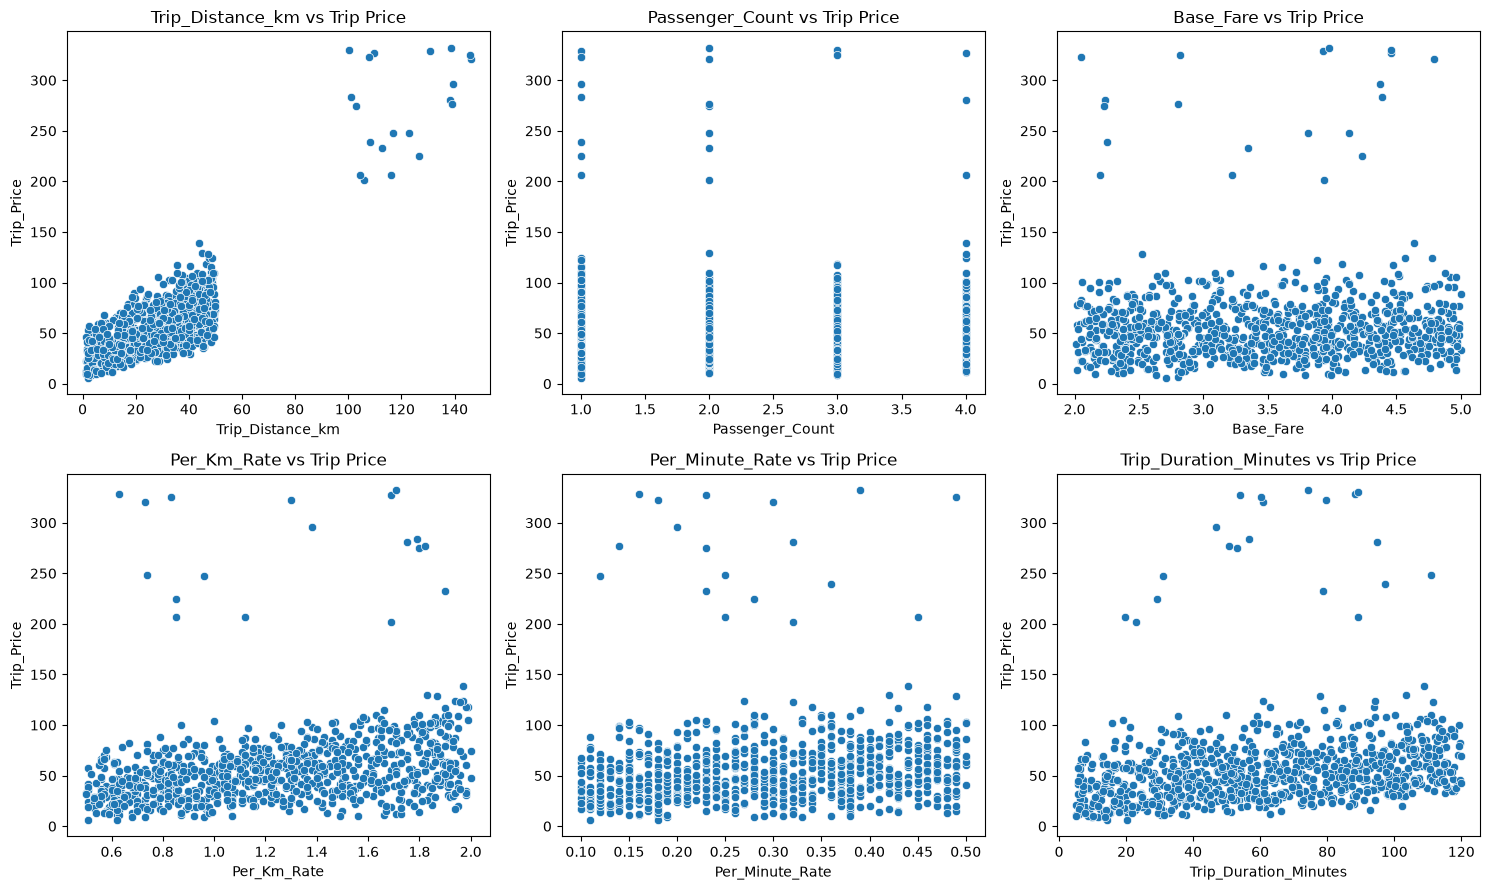

In [36]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

for ax, col in zip(
    axes.flatten(),
    numerical_features
):
    sns.scatterplot(
        data=df,
        x=col,
        y="Trip_Price",
        ax=ax
    )

    ax.set_title(f"{col} vs Trip Price")

plt.tight_layout()
plt.show()

In [37]:
correlation_matrix = df[numerical_features + ["Trip_Price"]].corr()

correlation_matrix

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000000,-0.048397,0.032218,-0.017041,-0.025902,-0.022102,0.849123
Passenger_Count,-0.048397,1.000000,0.022932,0.030213,0.034068,0.022845,-0.014223
Base_Fare,0.032218,0.022932,1.000000,0.003092,-0.019150,0.012035,0.035533
Per_Km_Rate,-0.017041,0.030213,0.003092,1.000000,0.029241,0.027199,0.275135
Per_Minute_Rate,-0.025902,0.034068,-0.019150,0.029241,1.000000,-0.024230,0.141226
Trip_Duration_Minutes,-0.022102,0.022845,0.012035,0.027199,-0.024230,1.000000,0.221211
Trip_Price,0.849123,-0.014223,0.035533,0.275135,0.141226,0.221211,1.000000


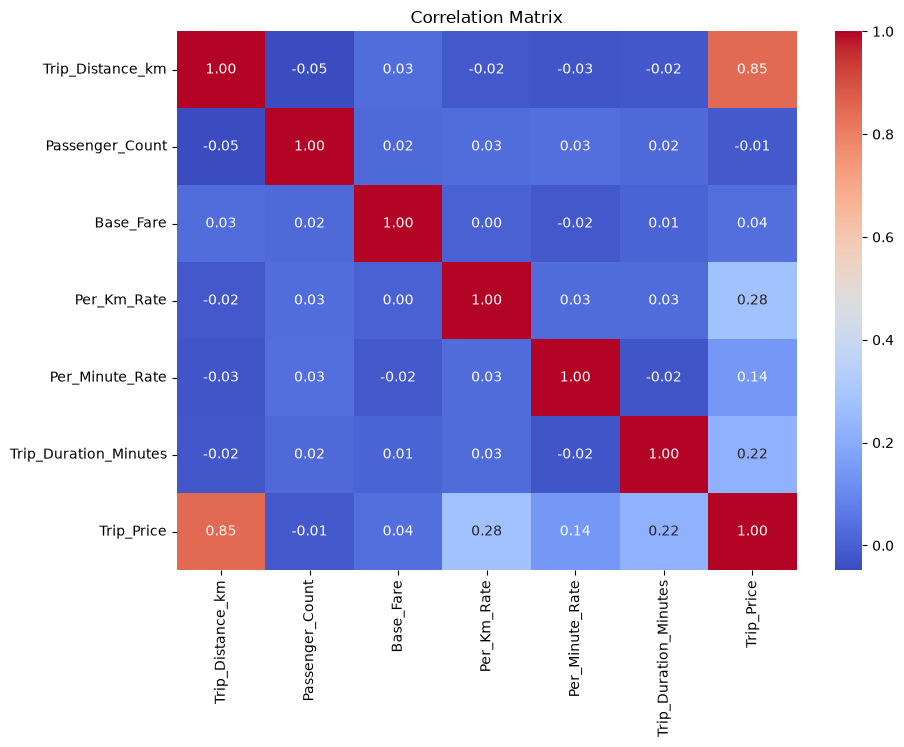

In [38]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [39]:
target_correlation = (
    correlation_matrix["Trip_Price"]
    .sort_values(ascending=False)
)

target_correlation

Trip_Price               1.000000
Trip_Distance_km         0.849123
Per_Km_Rate              0.275135
Trip_Duration_Minutes    0.221211
Per_Minute_Rate          0.141226
Base_Fare                0.035533
Passenger_Count         -0.014223
Name: Trip_Price, dtype: float64

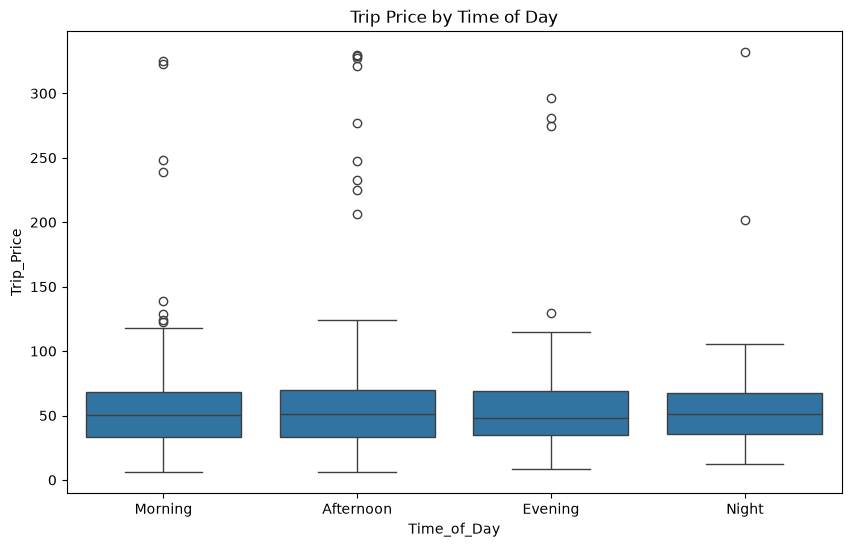

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Time_of_Day",
    y="Trip_Price"
)

plt.title("Trip Price by Time of Day")
plt.show()

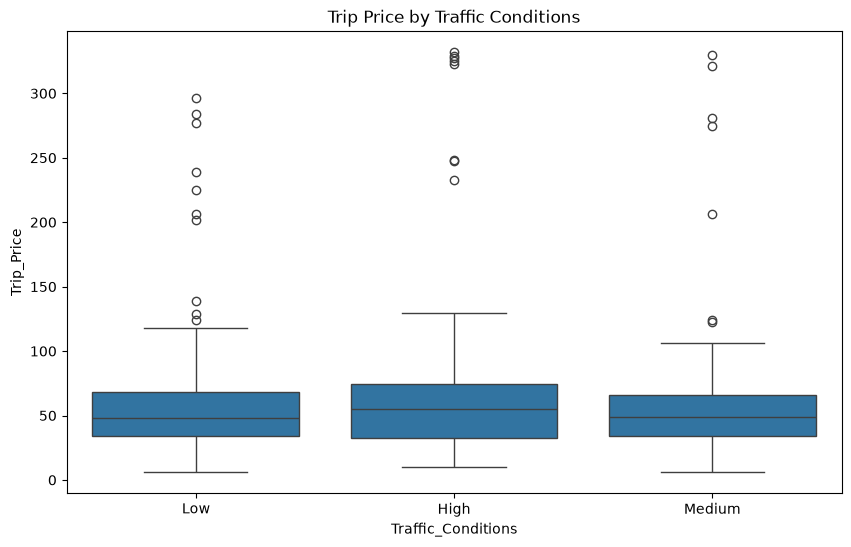

In [41]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Traffic_Conditions",
    y="Trip_Price"
)

plt.title("Trip Price by Traffic Conditions")
plt.show()

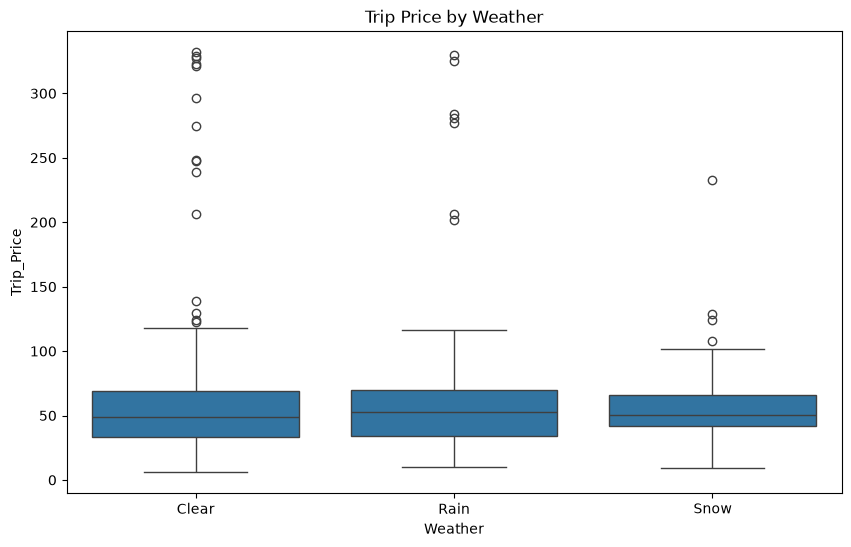

In [42]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Weather",
    y="Trip_Price"
)

plt.title("Trip Price by Weather")
plt.show()

## EDA Conclusions

- The dataset contains 1,000 observations and 11 columns.
- `Trip_Price` is the target variable.
- The dataset contains missing values across several features.
- Missing target values need to be removed before supervised learning.
- No duplicate rows were identified.
- `Trip_Distance_km` has a strong positive relationship with `Trip_Price`.
- `Trip_Duration_Minutes` and pricing-related variables may provide additional predictive information.
- Categorical variables such as time of day, traffic conditions, and weather may contain additional predictive information.
- Numerical features should be inspected for potential outliers before modeling.
- Numerical and categorical features will require different preprocessing strategies.